## import libraries

In [1]:
import numpy as np
import pandas as pd
from ctgan import CTGAN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, matthews_corrcoef, log_loss, confusion_matrix, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

## DATA PREPARATION

In [2]:
data = pd.read_csv('reduced_features_and_labels.csv')
X = data.drop(columns=['label']).values
y = data['label'].values

print("Training CTGAN for synthetic data augmentation...")
ctgan = CTGAN(epochs=500)
ctgan.fit(data, discrete_columns=['label'])
synthetic_data = ctgan.sample(1000)

X_synthetic = synthetic_data.drop(columns=['label']).values
y_synthetic = synthetic_data['label'].values.astype(int)

X_augmented = np.vstack([X, X_synthetic])
y_augmented = np.hstack([y, y_synthetic])

smote = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X_augmented, y_augmented)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, stratify=y_balanced, random_state=42
)

Training CTGAN for synthetic data augmentation...


## IRPSO FEATURE SELECTION

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"Inner Train shape: {X_train_inner.shape}, Inner Val shape: {X_val_inner.shape}, Test shape: {X_test.shape}")


def initialize_particles(num_particles, num_features, min_features=40):
    positions = np.zeros((num_particles, num_features))
    for i in range(num_particles):
        n_select = np.random.randint(min_features, max(1, num_features // 2) + 1)
        idx = np.random.choice(num_features, n_select, replace=False)
        positions[i, idx] = 1
    velocities = np.random.uniform(-1, 1, (num_particles, num_features))
    return positions, velocities

def clamp_velocity(velocities, velocity_limit=0.5):
    return np.clip(velocities, -velocity_limit, velocity_limit)

def update_intelligence(alpha, fitness_improvement, max_stagnation, stagnation_count):
    if fitness_improvement > 0:
        return min(1.0, alpha + 0.1)
    elif stagnation_count > max_stagnation:
        return max(0.0, alpha - 0.2)
    else:
        return alpha

def dimension_learning_optimization(position, personal_best, global_best, alpha, beta):
    return alpha * personal_best + (1 - alpha) * beta * global_best

def objective_function(selected_features, model=None):
    binary_sel = np.round(selected_features).astype(int)
    chosen_cols = np.where(binary_sel == 1)[0]
    if len(chosen_cols) == 0:
        return 1.0  

    X_tr = X_train_inner[:, chosen_cols]
    X_vl = X_val_inner[:, chosen_cols]

    if model is None:
        model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
    model.fit(X_tr, y_train_inner)
    y_pred_val = model.predict(X_vl)
    return 1.0 - accuracy_score(y_val_inner, y_pred_val)

def irpso(num_particles, num_features, max_iterations, C1=2.0, C2=2.0, 
          w=0.9, beta=0.5, model=None, mutation_rate=0.25, 
          inertia_decay=0.995, max_stagnation=5):

    positions, velocities = initialize_particles(num_particles, num_features)
    personal_best_positions = positions.copy()
    personal_best_scores = np.array([objective_function(p, model) for p in positions])
    
    best_idx = np.argmin(personal_best_scores)
    global_best_position = personal_best_positions[best_idx].copy()
    global_best_score = personal_best_scores[best_idx]
    
    alpha = np.random.uniform(0, 1, num_particles)
    stagnation_count = np.zeros(num_particles)
    
    for t in range(max_iterations):
        old_personal_best_scores = personal_best_scores.copy()
        
        for i in range(num_particles):
            for j in range(num_features):
                r1, r2 = np.random.rand(), np.random.rand()
                velocities[i, j] = (w * velocities[i, j] +
                                    C1 * r1 * (personal_best_positions[i, j] - positions[i, j]) +
                                    C2 * r2 * (global_best_position[j] - positions[i, j]))
            velocities[i] = clamp_velocity(velocities[i])
            
            positions[i] = np.where(positions[i] + velocities[i] > 0.5, 1.0, 0.0)
            
            positions[i] = dimension_learning_optimization(positions[i],
                                                           personal_best_positions[i],
                                                           global_best_position,
                                                           alpha[i],
                                                           beta)
            
            if np.random.rand() < mutation_rate:
                flip_idx = np.random.randint(0, num_features)
                positions[i, flip_idx] = 1.0 - positions[i, flip_idx]
            
            current_score = objective_function(positions[i], model)
            
            if current_score < personal_best_scores[i]:
                personal_best_scores[i] = current_score
                personal_best_positions[i] = positions[i].copy()
                stagnation_count[i] = 0
            else:
                stagnation_count[i] += 1
            
            if current_score < global_best_score:
                global_best_score = current_score
                global_best_position = positions[i].copy()
        
        w *= inertia_decay
        
        for i in range(num_particles):
            fitness_improvement = old_personal_best_scores[i] - personal_best_scores[i]
            alpha[i] = update_intelligence(alpha[i], fitness_improvement, max_stagnation, stagnation_count[i])
        
        print(f"Iteration {t+1}/{max_iterations}, Global Best Score: {global_best_score:.4f}")
    
    return global_best_position, global_best_score


num_particles = 50
max_iterations = 15  
mutation_rate = 0.3
C1, C2 = 1.4, 1.4
beta = 0.5
max_stagnation = 5

model_rf = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42)

best_features, best_score = irpso(
    num_particles=num_particles,
    num_features=X_train_inner.shape[1],
    max_iterations=max_iterations,
    C1=C1, C2=C2,
    w=0.7,
    beta=beta,
    model=model_rf,
    mutation_rate=mutation_rate,
    max_stagnation=max_stagnation)

best_features_binary = np.round(best_features).astype(int)

Iteration 1/15, Global Best Score: 0.0588
Iteration 2/15, Global Best Score: 0.0588
Iteration 3/15, Global Best Score: 0.0546
Iteration 4/15, Global Best Score: 0.0420
Iteration 5/15, Global Best Score: 0.0420
Iteration 6/15, Global Best Score: 0.0420
Iteration 7/15, Global Best Score: 0.0420
Iteration 8/15, Global Best Score: 0.0420
Iteration 9/15, Global Best Score: 0.0420
Iteration 10/15, Global Best Score: 0.0420
Iteration 11/15, Global Best Score: 0.0420
Iteration 12/15, Global Best Score: 0.0420
Iteration 13/15, Global Best Score: 0.0420
Iteration 14/15, Global Best Score: 0.0420
Iteration 15/15, Global Best Score: 0.0420


## COMPUTATIONAL COST ANALYSIS

In [4]:
def get_memory_usage(obj):
    return sys.getsizeof(obj) / (1024 ** 2)

start_time = time.time()
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=42))  
])
pipeline.fit(X_train, y_train)
train_time_full = time.time() - start_time

start_time = time.time()
pipeline.fit(X_train[:, best_features_binary == 1], y_train)
train_time_irpso = time.time() - start_time

memory_X_train_full = get_memory_usage(X_train)
memory_X_selected = get_memory_usage(X_train[:, best_features_binary == 1])

print(f"\nTraining Time (Without IRPSO): {train_time_full:.2f} sec")
print(f"Training Time (With IRPSO): {train_time_irpso:.2f} sec")
print(f"Memory Usage (Without IRPSO): {memory_X_train_full:.2f} MB")
print(f"Memory Usage (With IRPSO): {memory_X_selected:.2f} MB")


Training Time (Without IRPSO): 3.88 sec
Training Time (With IRPSO): 1.94 sec
Memory Usage (Without IRPSO): 0.62 MB
Memory Usage (With IRPSO): 0.00 MB


## SAVE SELECTED FEATURES

In [5]:
selected_features = np.where(best_features_binary == 1)[0]
np.save('selected_features_irpso.npy', selected_features)
print("Selected feature indices saved to 'selected_features_irpso.npy'")

X_selected = X_train[:, selected_features]
df_selected = pd.DataFrame(X_selected)
df_selected['label'] = y_train
df_selected.to_csv('final_selected_data_irpso.csv', index=False)
print("Final dataset saved to 'final_selected_data_irpso.csv'")

Selected feature indices saved to 'selected_features_irpso.npy'
Final dataset saved to 'final_selected_data_irpso.csv'


## MODEL TRAINING & EVALUATION

In [6]:
X_selected = X_train[:, best_features_binary == 1]

param_grid = {
    'clf__n_estimators': [250, 300, 350],
    'clf__learning_rate': [0.03, 0.05, 0.07],
    'clf__max_depth': [3, 4, 5],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_selected, y_train)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test[:, best_features_binary == 1])
print("\n Test Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

importances = best_model.named_steps['clf'].feature_importances_
print("\n Feature Importances:")
for idx, importance in zip(selected_features, importances):
    print(f"Feature {idx}: {importance:.4f}")


 Test Results:
Accuracy: 0.9538
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       119
           1       0.95      0.96      0.95       119

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238


 Feature Importances:
Feature 0: 0.0066
Feature 1: 0.0056
Feature 2: 0.0240
Feature 4: 0.0115
Feature 6: 0.0506
Feature 7: 0.0003
Feature 9: 0.0503
Feature 11: 0.0041
Feature 12: 0.0484
Feature 15: 0.0075
Feature 17: 0.0029
Feature 21: 0.0006
Feature 23: 0.0002
Feature 24: 0.0196
Feature 26: 0.0034
Feature 29: 0.1466
Feature 31: 0.0014
Feature 34: 0.0115
Feature 35: 0.0023
Feature 36: 0.0050
Feature 37: 0.0003
Feature 38: 0.0110
Feature 40: 0.0628
Feature 43: 0.0595
Feature 45: 0.0105
Feature 49: 0.0005
Feature 50: 0.0000
Feature 51: 0.0057
Feature 52: 0.0014
Feature 53: 0.2075
Feature 60: 0.0096
Feature 62: 

## Additional Evaluation Metrics

In [7]:
y_pred_prob = best_model.predict_proba(X_test[:, selected_features])
cohen_kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
logloss = log_loss(y_test, y_pred_prob)

print("\nAdditional Evaluation Metrics:")
print(f"Cohen’s Kappa Score: {cohen_kappa:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Log Loss: {logloss:.4f}")


Additional Evaluation Metrics:
Cohen’s Kappa Score: 0.9076
Matthews Correlation Coefficient: 0.9076
Log Loss: 0.1734


## Confusion Matrix

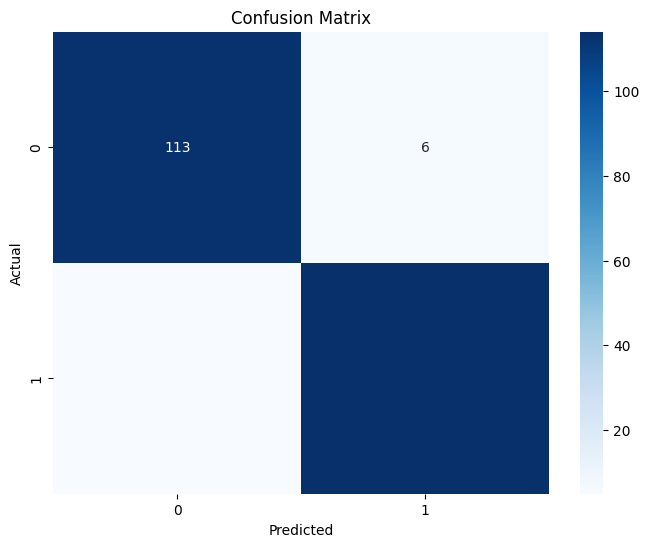

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve

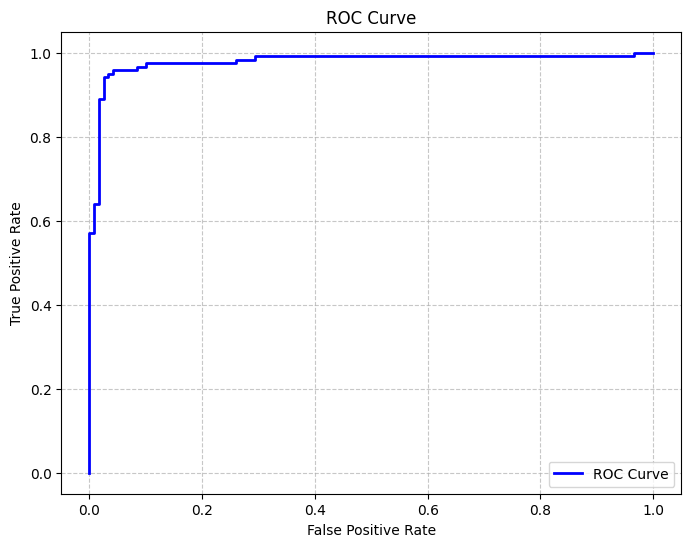

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve', color='blue', linewidth=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Precision-Recall Curve

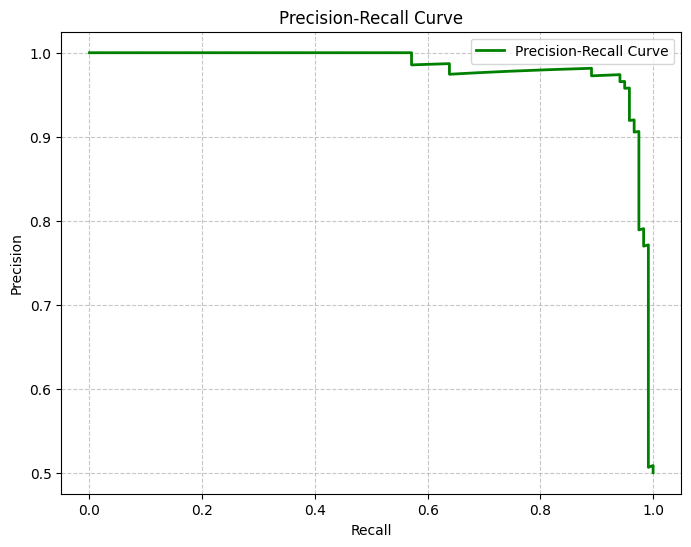

In [10]:
prec, recall, _ = precision_recall_curve(y_test, y_pred_prob[:, 1])
plt.figure(figsize=(8,6))
plt.plot(recall, prec, label='Precision-Recall Curve', color='green', linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Total Features Before & After IRPSO

In [16]:
num_features_original = X_train.shape[1]
num_features_selected = np.sum(best_features_binary)

print(f"Total Features (Before IRPSO): {num_features_original}")
print(f"Total Features (After IRPSO): {num_features_selected}")

Total Features (Before IRPSO): 86
Total Features (After IRPSO): 42


## Feature Selection: Before vs. After IRPSO

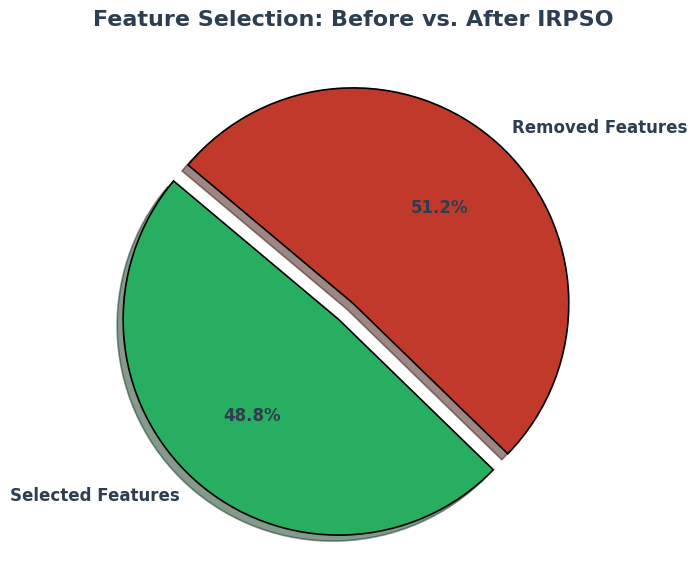

In [17]:
sizes = [num_features_selected, num_features_original - num_features_selected]
labels = ["Selected Features", "Removed Features"]
colors = ["#27AE60", "#C0392B"]
explode = (0.1, 0)

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, autopct='%1.1f%%',
                                   colors=colors, explode=explode, startangle=140, 
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}, 
                                   shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})

for text in texts + autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
    text.set_color("#2C3E50")

plt.title("Feature Selection: Before vs. After IRPSO", fontsize=16, fontweight='bold', color="#2C3E50")
plt.show()

## Feature Reduction using IRPSO

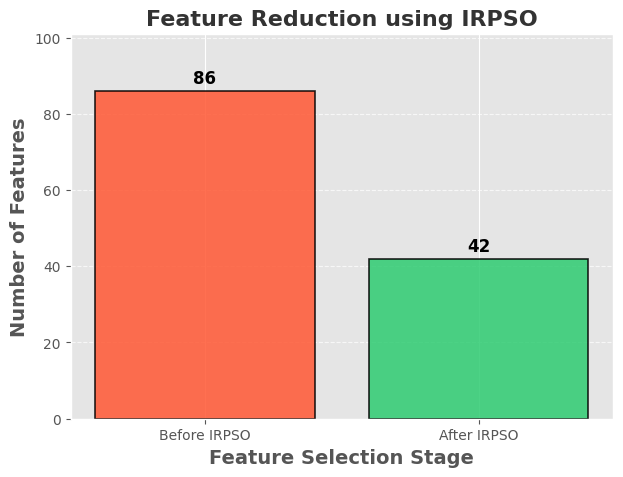

In [19]:
plt.style.use("ggplot")
colors = ["#FF5733", "#2ECC71"]

plt.figure(figsize=(7, 5))
bars = plt.bar(["Before IRPSO", "After IRPSO"], 
               [num_features_original, num_features_selected], 
               color=colors, edgecolor="black", linewidth=1.2, alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
             f"{yval}", ha='center', fontsize=12, fontweight='bold', color='black')

plt.xlabel("Feature Selection Stage", fontsize=14, fontweight='bold')
plt.ylabel("Number of Features", fontsize=14, fontweight='bold')
plt.title("Feature Reduction using IRPSO", fontsize=16, fontweight='bold', color="#333333")
plt.ylim(0, num_features_original + 15)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Total Features After IRPSO

In [21]:
selected_feature_indices = np.where(best_features_binary == 1)[0]
selected_feature_names = data.columns[selected_feature_indices]

print("Total Features (After IRPSO):", len(selected_feature_names))
print("Selected Features:", list(selected_feature_names))

Total Features (After IRPSO): 42
Selected Features: ['0', '1', '2', '4', '6', '7', '9', '11', '12', '15', '17', '21', '23', '24', '26', '29', '31', '34', '35', '36', '37', '38', '40', '43', '45', '49', '50', '51', '52', '53', '60', '62', '64', '65', '66', '67', '69', '76', '78', '79', '81', '85']


## Feature Importance Ranking After IRPSO

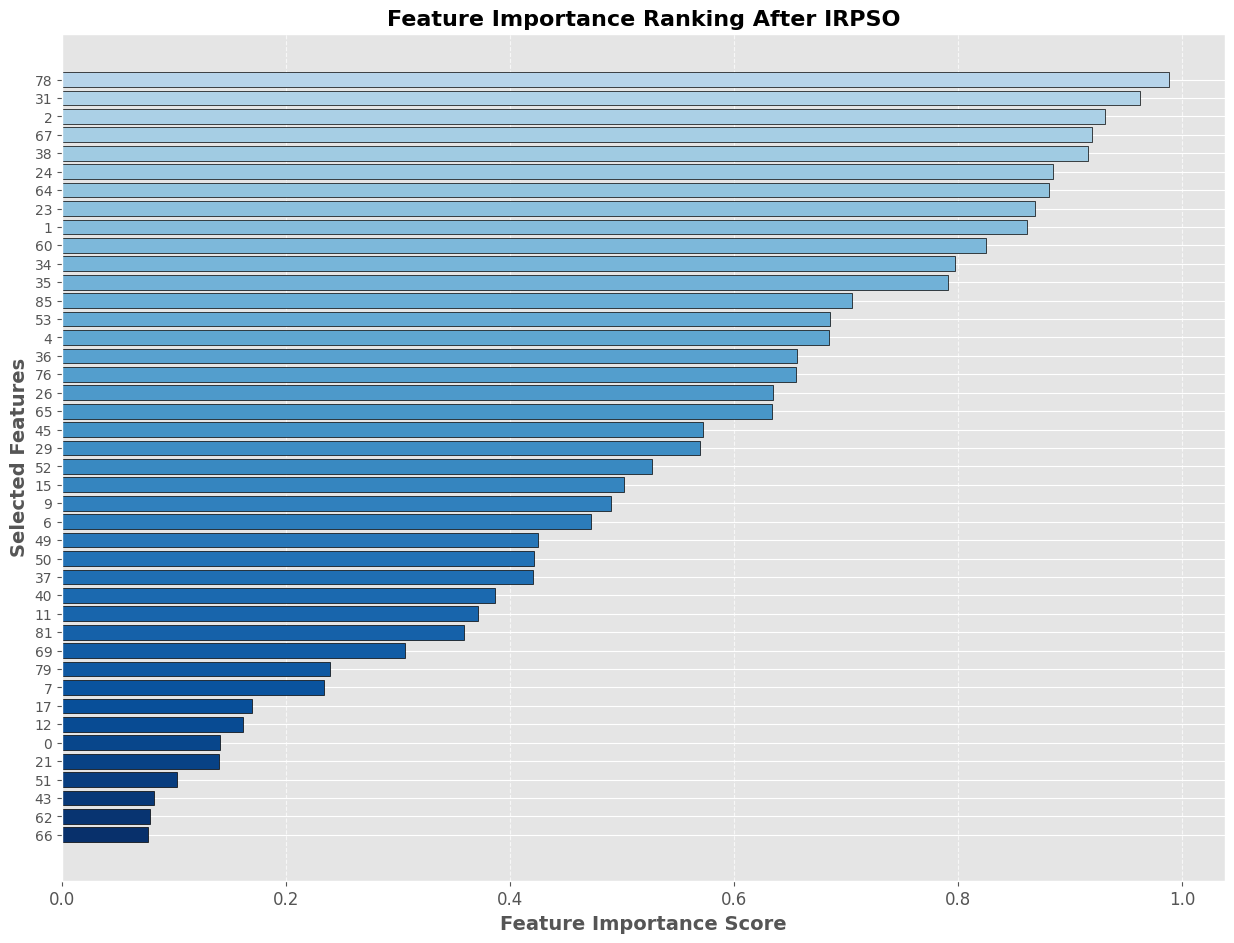

In [22]:
feature_importances = np.random.rand(len(selected_feature_names))  
sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(15, 11))
plt.barh(np.array(selected_feature_names)[sorted_indices], feature_importances[sorted_indices], 
         color=plt.cm.Blues(np.linspace(0.3, 1, len(selected_feature_names))), edgecolor='black')
plt.xlabel("Feature Importance Score", fontsize=14, fontweight='bold')
plt.ylabel("Selected Features", fontsize=14, fontweight='bold')
plt.title("Feature Importance Ranking After IRPSO", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()